In [12]:
!pip install pandas numpy matplotlib seaborn jupyter


# Student Performance Analysis
## Task 1 - Data Science Internship
This notebook explores the Student Performance dataset to understand factors affecting grades.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset
We load the CSV file using pandas `read_csv()`.

In [14]:
#dataset
import requests, zipfile, io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extract('student-mat.csv')

df = pd.read_csv('student-mat.csv', sep=';')
print("Loaded! Shape:", df.shape)
df.head()

Loaded! Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore & Clean Data
Check shape, data types, missing values, and duplicates.

In [15]:
# Shape of dataset
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("\nAfter removing duplicates:", df.shape)

Shape: (395, 33)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
school

## 3. Analysis Questions
Answering key questions about student performance.

In [16]:
# Q1: Average final grade (G3)
avg_grade = df['G3'].mean()
print(f"Q1. Average Final Grade (G3): {avg_grade:.2f}")

# Q2: Students who scored above 15
above_15 = df[df['G3'] > 15]
print(f"Q2. Students scoring above 15: {len(above_15)}")

# Q3: Correlation between study time and G3
correlation = df['studytime'].corr(df['G3'])
print(f"Q3. Correlation (Study Time vs G3): {correlation:.4f}")

# Q4: Gender performance comparison
gender_avg = df.groupby('sex')['G3'].mean()
print("\nQ4. Average Grade by Gender:")
print(gender_avg)

Q1. Average Final Grade (G3): 10.42
Q2. Students scoring above 15: 40
Q3. Correlation (Study Time vs G3): 0.0978

Q4. Average Grade by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


## 4. Visualizations
Visual exploration of grades, study time, and gender performance.

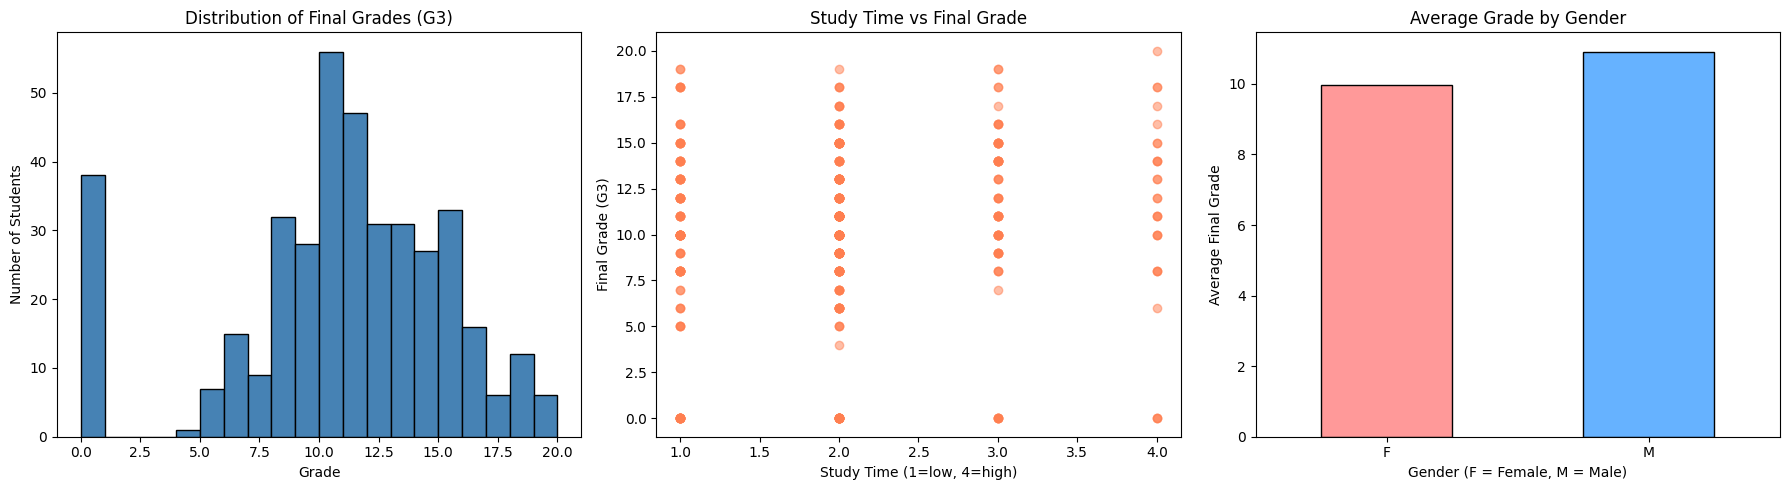

✅ All plots generated!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Histogram of G3 grades ---
axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Number of Students')

# --- Plot 2: Scatterplot - Study Time vs G3 ---
axes[1].scatter(df['studytime'], df['G3'], alpha=0.5, color='coral')
axes[1].set_title('Study Time vs Final Grade')
axes[1].set_xlabel('Study Time (1=low, 4=high)')
axes[1].set_ylabel('Final Grade (G3)')

# --- Plot 3: Bar chart - Gender vs Average Grade ---
gender_avg.plot(kind='bar', ax=axes[2], color=['#FF9999', '#66B2FF'], edgecolor='black')
axes[2].set_title('Average Grade by Gender')
axes[2].set_xlabel('Gender (F = Female, M = Male)')
axes[2].set_ylabel('Average Final Grade')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print("✅ All plots generated!")

## 5. Conclusion

### Key Findings:
- **Average Final Grade (G3):** 10.42 out of 20
- **Students scoring above 15:** 40 students
- **Study Time vs Grade Correlation:** 0.0978 (weak positive correlation)
  - Students who study more tend to score slightly higher
- **Gender Performance:**
  - Female average: 9.97
  - Male average: 10.91
  - Male students perform slightly better on average

### Summary:
The dataset has 395 students with no missing values or duplicates.
Study time has a weak but positive effect on final grades.
Overall performance is moderate with an average grade of 10.42/20.

In [18]:
print("=" * 40)
print("   STUDENT PERFORMANCE SUMMARY")
print("=" * 40)
print(f"Total Students       : {len(df)}")
print(f"Average Grade (G3)   : {avg_grade:.2f}")
print(f"Students above 15    : {len(above_15)}")
print(f"Study Time Correlation: {correlation:.4f}")
print(f"Female Avg Grade     : {gender_avg['F']:.2f}")
print(f"Male Avg Grade       : {gender_avg['M']:.2f}")
print("=" * 40)
print("✅ Task 1 Complete!")

   STUDENT PERFORMANCE SUMMARY
Total Students       : 395
Average Grade (G3)   : 10.42
Students above 15    : 40
Study Time Correlation: 0.0978
Female Avg Grade     : 9.97
Male Avg Grade       : 10.91
✅ Task 1 Complete!
